# Model Analyst — VideoRoPE vs 1D RoPE (data that)

Ve **phan phoi toa do vi tri** (position allocation) dua tren **sample dau tien trong
tap train** (timestamps, so frame, so segment that), bam sat config trong
[`ablation_study_1.ipynb`](ablation_study_1.ipynb):

| Tham so | Gia tri | Y nghia |
|---|---|---|
| `max_frames` | **25** | so frame visual / clip |
| `max_segments` | **15** | so segment text |
| `max_seg_tokens` | **128** | so token / segment |
| region | **4x4 = 16** | so vung khong gian / frame (`visual_features: [N, 16, 1152]`) |

Toa do vi tri tinh theo [`fusion_encoder.py` `_build_positions`](../model/fusion_encoder.py#L236-L248);
tan so RoPE theo [`components.py` `VideoRoPE2D`](../model/components.py#L64-L107).

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# === Kich thuoc DU LIEU THAT (khop CFG trong ablation_study_1.ipynb) ===
MAX_FRAMES     = 25      # so frame visual / clip
MAX_SEGMENTS   = 15      # so segment text
MAX_SEG_TOKENS = 128     # so token / segment
GRID           = 4       # region xep luoi 4x4
N_REGIONS      = GRID * GRID          # = 16 region / frame

# So frame lay de ve Hinh 1 (lay moc thoi gian den frame thu N_SHOW_FRAMES)
N_SHOW_FRAMES  = 5

SEQ_VIS = MAX_FRAMES * N_REGIONS        # 25*16 = 400  visual tokens (cross-attn key)
SEQ_SEG = MAX_SEGMENTS * MAX_SEG_TOKENS  # 15*128 = 1920 segment tokens (self-attn)

# === Config RoPE (fusion_encoder.py / components.py) ===
HEAD_DIM = 64                 # dim // n_heads = 1024 // 16
BASE_TEMPORAL = 500_000.0
BASE_SPATIAL  = 10_000.0
N_T = HEAD_DIM // 2           # 32 dims temporal (VideoRoPE)
N_R = HEAD_DIM // 4           # 16 dims row
N_C = HEAD_DIM - N_T - N_R    # 16 dims col

def inv_freq(n_dim, base):
    """Tan so nghich dao cua RoPE: 1 / base^(2i/n_dim), i = 0..n_dim/2-1."""
    return 1.0 / (base ** (np.arange(0, n_dim, 2, dtype=float) / n_dim))

print(f'max_frames={MAX_FRAMES}, max_segments={MAX_SEGMENTS}, '
      f'max_seg_tokens={MAX_SEG_TOKENS}, region={GRID}x{GRID}={N_REGIONS}')
print(f'Hinh 1 lay {N_SHOW_FRAMES} frame dau (moc thoi gian den frame thu {N_SHOW_FRAMES})')
print(f'VideoRoPE split: n_t={N_T}, n_r={N_R}, n_c={N_C} (head_dim={HEAD_DIM})')

max_frames=25, max_segments=15, max_seg_tokens=128, region=4x4=16
Hinh 1 lay 5 frame dau (moc thoi gian den frame thu 5)
VideoRoPE split: n_t=32, n_r=16, n_c=16 (head_dim=64)


## Load sample dau tien trong tap train

Train split co shuffle -> dat `random.seed(0)` de tai lap dung mot sample. Lay timestamps
frame/segment that va mask de biet so frame/segment hop le.

In [20]:
from pathlib import Path
import sys, random

# Tu dong tim BASE_DIR (thu muc chua source/ va data/)
cwd = Path.cwd().resolve()
BASE_DIR = next((c for c in [cwd, *cwd.parents]
                 if (c / 'source' / 'train' / 'dataset.py').exists() and (c / 'data').exists()),
                Path('e:/aic'))
sys.path.insert(0, str(BASE_DIR / 'source'))
sys.path.insert(0, str(BASE_DIR / 'source' / 'train'))
print('BASE_DIR:', BASE_DIR)

try:
    from dataset import VietnameseNewsDataset
    random.seed(0)                       # tai lap 'sample dau tien' du train co shuffle
    ds = VietnameseNewsDataset(
        split='train', base_dir=str(BASE_DIR),
        max_frames=MAX_FRAMES, max_segments=MAX_SEGMENTS,
        max_seg_tokens=MAX_SEG_TOKENS, visual_feature_subdir='siglip2',
    )
    sample = ds[0]
    vmask = sample['visual_mask'].numpy().astype(bool)
    smask = sample['segment_mask'].numpy().astype(bool)
    ts_all = sample['frame_timestamps'].numpy()[vmask]      # timestamps frame hop le (s)
    seg_ts = sample['seg_timestamps'].numpy()[smask]        # timestamps segment hop le (s)
    shot = sample['shot_id']
    USING_REAL = True
except Exception as e:
    print('[!] Khong load duoc data that:', repr(e))
    print('    -> dung gia tri gia lap de van ve duoc hinh.')
    ts_all = np.linspace(0, 78, 18)
    seg_ts = np.array([1.4, 17.6, 27.1, 52.0])
    shot = '(synthetic fallback)'
    USING_REAL = False

# Lay moc thoi gian den frame thu N_SHOW_FRAMES (5 frame dau)
ts = ts_all[:N_SHOW_FRAMES]
n_f, n_s = len(ts), len(seg_ts)
print(f"Sample: {shot} | real={USING_REAL} | tong {len(ts_all)} frame hop le, lay {n_f} frame dau")
print('frame timestamps lay (s):', np.round(ts, 1).tolist())
print('seg   timestamps     (s):', np.round(seg_ts, 1).tolist())

BASE_DIR: E:\aic
Sample: K15_V030_016 | real=True | tong 18 frame hop le, lay 5 frame dau
frame timestamps lay (s): [0.0, 4.599999904632568, 7.400000095367432, 10.100000381469727, 12.300000190734863]
seg   timestamps     (s): [1.5, 18.5, 27.100000381469727, 35.5, 43.79999923706055, 68.5, 74.0]


## Hinh 1 — 3D position allocation tren SAMPLE THAT (5 frame dau)

Cung tap token (`5 frame dau` x luoi 4x4 = 80 token), khac cach gan toa do:
- **(a) 1D RoPE**: token thu k -> `(k, k, k)` -> **duong cheo manh**, khong co cau truc khong gian.
- **(b) VideoRoPE 2D (Diagonal Layout)**: dung **timestamp that** lam toa do thoi gian,
  khong gian dich cheo theo thoi gian (`x = t + col, y = t + row`) -> moi frame la mot
  **luoi 4x4 toa quanh duong cheo**, dung kieu hinh VideoRoPE trong bao cao.

Ca 2 panel ve cung 80 token (5 frame x 16 region)


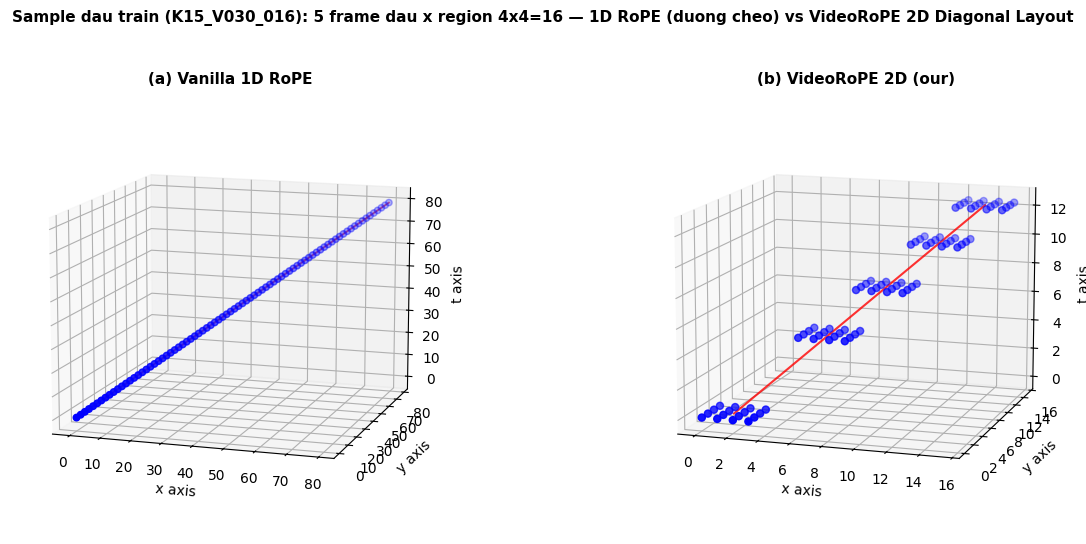

In [22]:
# CUNG tap token tu sample THAT: 5 frame dau x 16 region = 80 token
toks = [(i, j) for i in range(n_f) for j in range(N_REGIONS)]

# 1D RoPE                     : token thu k -> (k, k, k)
c1 = np.array([[k, k, k] for k in range(len(toks))], dtype=float)
# VideoRoPE 2D Diagonal Layout: x = ts+col, y = ts+row, t = ts (timestamp THAT)
cd = np.array([[ts[i] + j % GRID, ts[i] + j // GRID, ts[i]] for (i, j) in toks])
print(f'Ca 2 panel ve cung {len(toks)} token ({n_f} frame x {N_REGIONS} region)')

fig = plt.figure(figsize=(13, 5.5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(c1[:, 0], c1[:, 1], c1[:, 2], color='red', lw=1.2, alpha=0.6)
ax1.scatter(c1[:, 0], c1[:, 1], c1[:, 2], c='blue', s=22, depthshade=True)
ax1.set_xlabel('x axis'); ax1.set_ylabel('y axis'); ax1.set_zlabel('t axis')
ax1.set_title(f'(a) Vanilla 1D RoPE', fontweight='bold', fontsize=11)
ax1.view_init(elev=12, azim=-72)

ax2 = fig.add_subplot(122, projection='3d')
centers = np.array([[t + (GRID - 1) / 2, t + (GRID - 1) / 2, t] for t in ts])
ax2.plot(centers[:, 0], centers[:, 1], centers[:, 2], color='red', lw=1.5, alpha=0.8)
ax2.scatter(cd[:, 0], cd[:, 1], cd[:, 2], c='blue', s=26, depthshade=True)
ax2.set_xlabel('x axis'); ax2.set_ylabel('y axis'); ax2.set_zlabel('t axis')
ax2.set_title(f'(b) VideoRoPE 2D (our)', fontweight='bold', fontsize=11)
ax2.view_init(elev=12, azim=-72)

fig.suptitle(f'Sample dau train ({shot}): {n_f} frame dau x region 4x4=16 — '
             '1D RoPE (duong cheo) vs VideoRoPE 2D Diagonal Layout',
             fontsize=11, fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

**Nhan xet.** Voi *5 frame dau cua sample that*, 1D RoPE nen tat ca vao mot truc tuyen
tinh (duong cheo) — mat cau truc khong gian. VideoRoPE 2D Diagonal Layout dung timestamp
that lam truc thoi gian va dich cheo khong gian (`x=t+col, y=t+row`) -> moi frame mot luoi
4x4 doc duong cheo; khoang cach giua cac luoi phan anh dung khoang thoi gian that giua cac frame.

**Luu y ve code:** `_build_positions` hien dat `frame_r=row, frame_c=col` (khong cong `+t`)
+ `frame_t=frame_ts*delta` — tuc phan gan chi so vi tri dang theo kieu **M-RoPE** (truc
khong gian doc lap), chua phai diagonal layout day du. Diem VideoRoPE model **da co** la
*low-frequency temporal allocation* (`base_temporal=5e5 >> base_spatial=1e4`, Hinh 2). De
model khop dung hinh diagonal, can them offset `+t` vao `frame_r`/`frame_c`.

## Hinh 2 — Temporal Frequency Allocation in VideoRoPE

Token index chay het chuoi token temporal = `max_segments x max_seg_tokens = 15 x 128 = 1920`
(chuoi segment token ma self-attention xu ly). Ve `cos(t·ω(d))` cho cac chieu temporal.

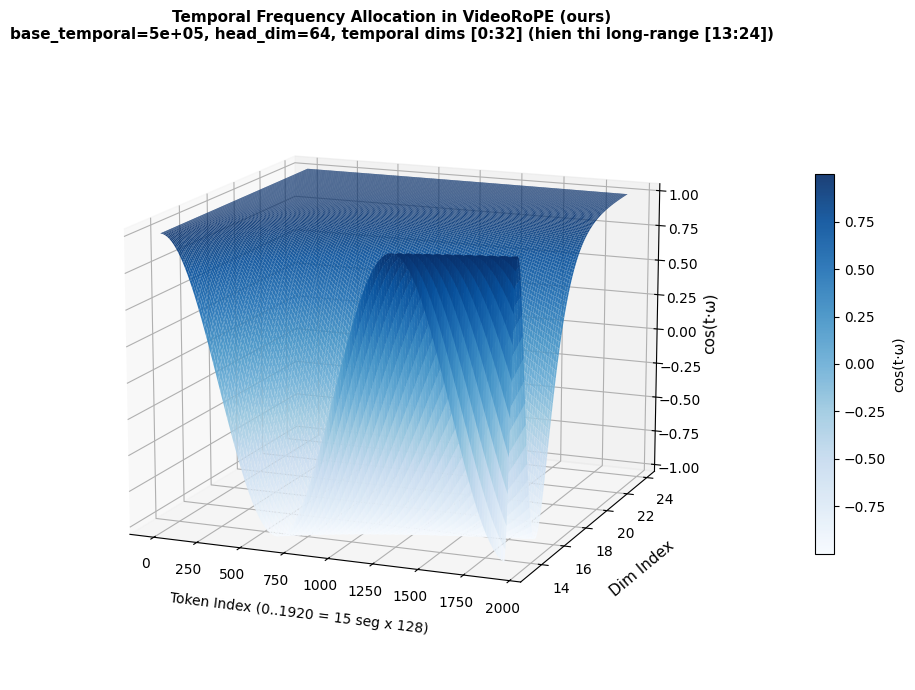

In [23]:
# omega(d) = base_temporal^(-d / N_T): khoi temporal co n_t=32 dims; dim cao -> tan so
# thap -> buoc song dai -> wavefront cheo. Cua so [13:24] o nua sau khoi temporal
# (long-range) cho ~0.02-1.5 chu ky tren SEQ_SEG=1920 token -> wavefront thoai nhu hinh goc.
max_token = SEQ_SEG                 # = 15 * 128 = 1920
dim_lo, dim_hi = 13, 24
tokens_ax = np.linspace(0, max_token, 600)
dims = np.linspace(dim_lo, dim_hi, 140)
T, D = np.meshgrid(tokens_ax, dims)
omega = BASE_TEMPORAL ** (-D / N_T)
Z = np.cos(T * omega)

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(T, D, Z, cmap='Blues', alpha=0.92, linewidth=0,
                       antialiased=True, rcount=140, ccount=160)
ax.set_xlabel('Token Index (0..1920 = 15 seg x 128)', fontsize=10, labelpad=10)
ax.set_ylabel('Dim Index', fontsize=11, labelpad=10)
ax.set_zlabel('cos(t·ω)', fontsize=11)
ax.set_zlim(-1.05, 1.05)
ax.set_title(f'Temporal Frequency Allocation in VideoRoPE (ours)\n'
             f'base_temporal={BASE_TEMPORAL:.0e}, head_dim={HEAD_DIM}, '
             f'temporal dims [0:{N_T}] (hien thi long-range [{dim_lo}:{dim_hi}])',
             fontweight='bold', fontsize=11)
ax.view_init(elev=14, azim=-68)
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label='cos(t·ω)')
fig.tight_layout()
plt.show()

**Nhan xet.** `base_temporal=5e5` lon khien tan so cac chieu temporal bac cao (dim ~13-24)
**giam ve gan 0** -> buoc song dai. Day la *low-frequency temporal allocation*: giu quan
he thoi gian **tam xa** ma khong bi cuon vong (aliasing). Day la dac trung VideoRoPE model da co.

## Hinh 2b — So sanh heatmap tan so temporal: 1D RoPE vs VideoRoPE 2D

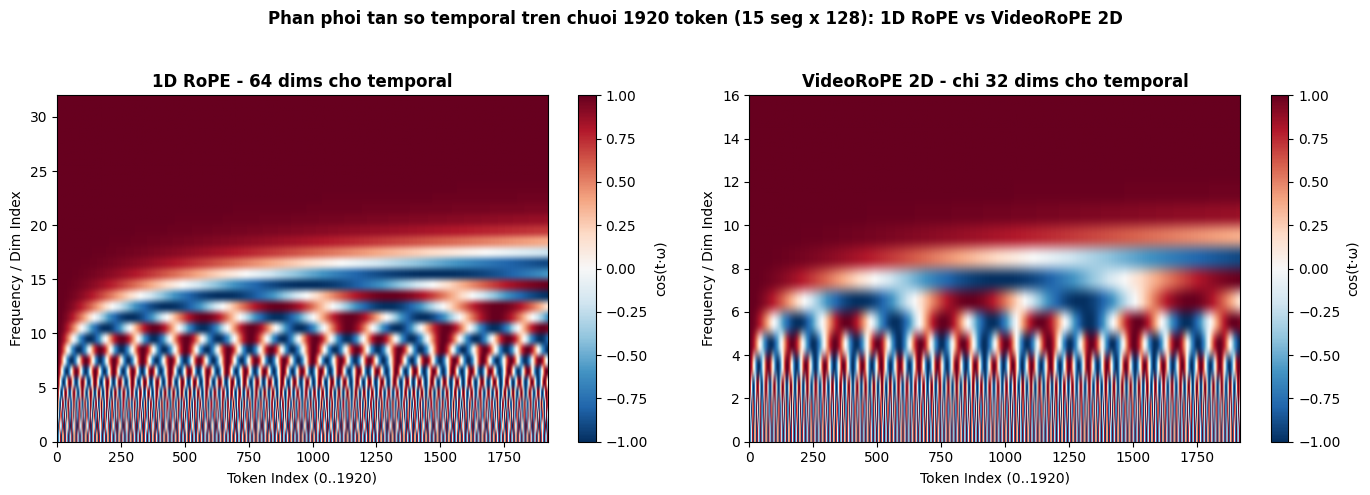

In [24]:
inv_1 = inv_freq(HEAD_DIM, BASE_TEMPORAL)   # 1D RoPE: ca head_dim=64 cho temporal
inv_t = inv_freq(N_T, BASE_TEMPORAL)        # VideoRoPE: chi n_t=32 dims cho temporal
tokens_ax = np.arange(0, SEQ_SEG, 4, dtype=float)   # 0..1920
g1 = np.cos(np.outer(inv_1, tokens_ax))
gv = np.cos(np.outer(inv_t, tokens_ax))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, g, title, n in [
    (axes[0], g1, f'1D RoPE - {HEAD_DIM} dims cho temporal', inv_1.shape[0]),
    (axes[1], gv, f'VideoRoPE 2D - chi {N_T} dims cho temporal', inv_t.shape[0]),
]:
    im = ax.imshow(g, aspect='auto', origin='lower', cmap='RdBu_r',
                   extent=[0, SEQ_SEG, 0, n], vmin=-1, vmax=1)
    ax.set_xlabel('Token Index (0..1920)'); ax.set_ylabel('Frequency / Dim Index')
    ax.set_title(title, fontweight='bold')
    fig.colorbar(im, ax=ax, label='cos(t·ω)')
fig.suptitle('Phan phoi tan so temporal tren chuoi 1920 token (15 seg x 128): '
             '1D RoPE vs VideoRoPE 2D', fontsize=12, fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

**Nhan xet.** 1D RoPE dung toan bo `head_dim=64` cho mot truc thoi gian; VideoRoPE chia
bot nua so chieu (`n_t=32`) cho khong gian — danh doi do phan giai temporal de lay kha
nang ma hoa cau truc khong gian 2D cua 16 region/frame.

## Hinh 3 — So do ket noi Attention: Full vs Local vs Global vs Local+Global

Mo phong **Hinh 2 (Longformer)** nhung cho **cross-attention** cua Fusion Encoder. Bieu do
**xay truc tiep tu cong thuc tao mask** tren timestamp THAT cua sample dau train — **khong chay
model** (day la *gia dinh viec tinh toan*, khong phai doc lai attention weight sau khi forward).

| Panel | Co che | Nguon code | Ket noi (key cho moi segment query) |
|---|---|---|---|
| **(a) Full** | "binh thuong" = bo Local-Global | [`FusionEncoderNoFilterVideoRoPE`](../model/fusion_encoder.py#L210) | moi segment ↔ **moi** frame (toan bo visual seq) |
| **(b) Local** | window mask | [`_build_local_mask`](../model/fusion_encoder.py#L365-L375) | chi frame co `|t_seg − t_frame| ≤ 8s` |
| **(c) Global** | region-pooled token | [`global_ca`](../model/blocks.py#L154-L157) + [`_build_global_tokens`](../model/fusion_encoder.py#L358-L363) | moi segment ↔ **16** global token (1/region, mean qua frame) |
| **(d) Local+Global** | `z = y + local + global` | [`FusionBlockLocalGlobal`](../model/blocks.py#L138-L160) | band thoi gian (Local) **+** khoi global |

Moi o = 1 block `128 token × 16 region`. Mau **xanh** = duoc attend, **trang** = bi mask.
Tham so khop `CFG` trong [`ablation_study_1.ipynb`](ablation_study_1.ipynb): `window = 8s`, `global tokens = 16`.

Sample K15_V030_016 | segment hop le M=7, frame hop le N=18, window=8s, global_tokens=16
So cap query-key (token-level; query = M x 128, key tuy co che):
  (a) Full         :      258,048   100.0%
  (b) Local        :       45,056    17.5%
  (c) Global       :       14,336     5.6%
  (d) Local+Global :       59,392    23.0%  -> tiet kiem 77% so voi Full


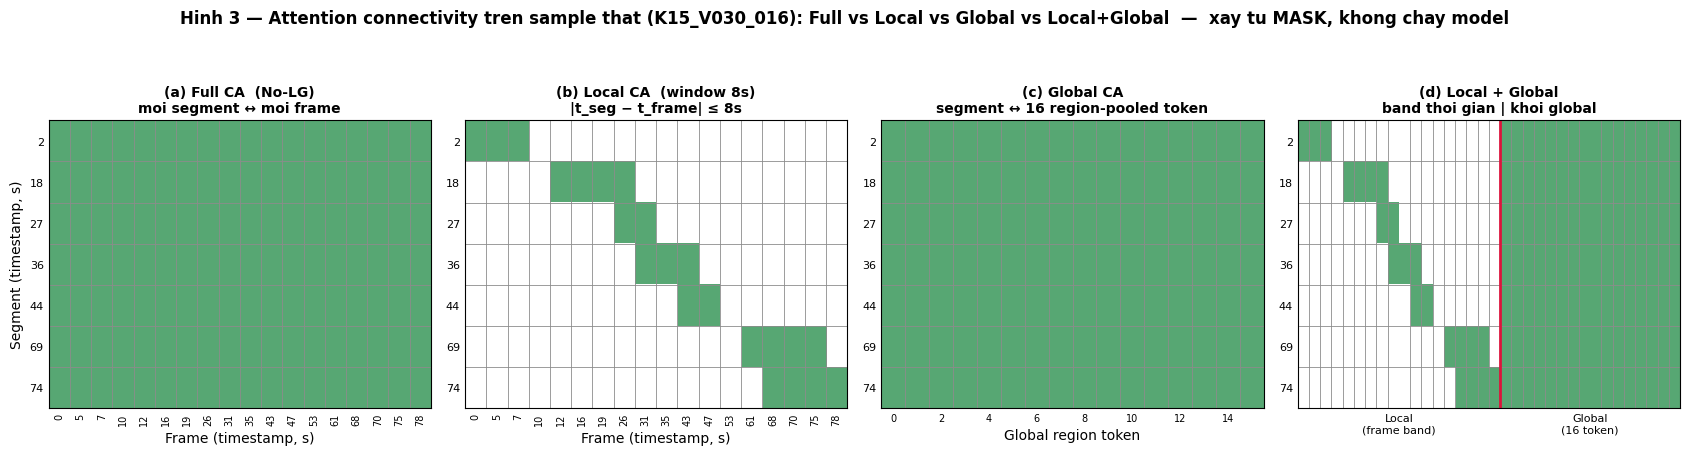

In [25]:
# =====================================================================
# Hinh 3 — So do ket noi Attention (Full / Local / Global / Local+Global)
# Xay TRUC TIEP tu cong thuc tao mask trong model — KHONG chay model.
#   Full   : FusionEncoderNoFilterVideoRoPE       -> full CA (chi mask frame hop le)
#   Local  : FusionEncoderNoFilterVideoRoPELG._build_local_mask -> |t_seg - t_frame| <= 8s
#   Global : global_ca + _build_global_tokens     -> moi segment attend 16 region-pooled token
#   LG     : FusionBlockLocalGlobal: z = y + local_out + global_out
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# --- (0) LOAD DATA FIRST: tai su dung sample da load o tren; neu thieu thi load lai ---
def _load_first_train_sample():
    from pathlib import Path
    import sys, random
    cwd = Path.cwd().resolve()
    base = next((c for c in [cwd, *cwd.parents]
                 if (c / 'source' / 'train' / 'dataset.py').exists() and (c / 'data').exists()),
                Path('e:/aic'))
    sys.path.insert(0, str(base / 'source')); sys.path.insert(0, str(base / 'source' / 'train'))
    from dataset import VietnameseNewsDataset
    random.seed(0)                              # tai lap dung 'sample dau train' du co shuffle
    ds = VietnameseNewsDataset(split='train', base_dir=str(base), max_frames=25,
                               max_segments=15, max_seg_tokens=128, visual_feature_subdir='siglip2')
    s = ds[0]
    vm = s['visual_mask'].numpy().astype(bool); sm = s['segment_mask'].numpy().astype(bool)
    return s['frame_timestamps'].numpy()[vm], s['seg_timestamps'].numpy()[sm], s['shot_id']

if {'seg_ts', 'ts_all'} <= set(dir()):          # da load o cell "Load sample dau tien" o tren
    frame_t = np.asarray(ts_all, float); seg_t = np.asarray(seg_ts, float)
    shot_id = shot if 'shot' in dir() else '(sample dau train)'
else:
    frame_t, seg_t, shot_id = _load_first_train_sample()
    frame_t = np.asarray(frame_t, float); seg_t = np.asarray(seg_t, float)

# --- Config khop ablation_study_1 CFG + fusion_encoder.py ---
WINDOW_SECONDS = 8.0                              # CFG['lg_window_seconds']
N_REGIONS_  = N_REGIONS if 'N_REGIONS' in dir() else 16
SEG_TOKENS_ = MAX_SEG_TOKENS if 'MAX_SEG_TOKENS' in dir() else 128
N_GLOBAL    = N_REGIONS_                          # _build_global_tokens -> 16 region-pooled token
M, N = len(seg_t), len(frame_t)

# --- (1) Xay mask o muc segment x frame (moi o = 1 block 128 token x 16 region) ---
dt       = np.abs(seg_t[:, None] - frame_t[None, :])   # [M, N] khoang cach thoi gian (s)
full_sf  = np.ones((M, N))                             # (a) Full : moi segment <-> moi frame
local_sf = (dt <= WINDOW_SECONDS).astype(float)        # (b) Local: |t_seg - t_frame| <= 8s
glob_sf  = np.ones((M, N_GLOBAL))                      # (c) Global: segment <-> 16 global token
comb_sf  = np.concatenate([local_sf, glob_sf], axis=1) # (d) [Local band | Global block]

# --- (2) Chi phi token-level (so cap query-key thuc su) ---
p_full  = (M * SEG_TOKENS_) * (N * N_REGIONS_)
p_local = local_sf.sum() * SEG_TOKENS_ * N_REGIONS_
p_glob  = (M * SEG_TOKENS_) * N_GLOBAL
p_lg    = p_local + p_glob
print(f'Sample {shot_id} | segment hop le M={M}, frame hop le N={N}, '
      f'window={WINDOW_SECONDS:.0f}s, global_tokens={N_GLOBAL}')
print('So cap query-key (token-level; query = M x 128, key tuy co che):')
print(f'  (a) Full         : {p_full:>12,.0f}   100.0%')
print(f'  (b) Local        : {p_local:>12,.0f}   {100*p_local/p_full:5.1f}%')
print(f'  (c) Global       : {p_glob:>12,.0f}   {100*p_glob/p_full:5.1f}%')
print(f'  (d) Local+Global : {p_lg:>12,.0f}   {100*p_lg/p_full:5.1f}%  '
      f'-> tiet kiem {100*(1-p_lg/p_full):.0f}% so voi Full')

# --- (3) Ve 4 panel kieu Longformer Hinh 2 (xanh = attend, trang = bi mask) ---
GREEN = ListedColormap(['white', '#57A773'])
def _grid(ax, mat):
    ax.imshow(mat, cmap=GREEN, vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(np.arange(-0.5, mat.shape[1] + 0.5, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mat.shape[0] + 0.5, 1), minor=True)
    ax.grid(which='minor', color='0.55', lw=0.6)
    ax.tick_params(which='both', length=0)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
ft = [f'{t:.0f}' for t in frame_t]
st = [f'{t:.0f}' for t in seg_t]

_grid(axes[0], full_sf)
axes[0].set_title('(a) Full CA  (No-LG)\nmoi segment ↔ moi frame', fontweight='bold', fontsize=10)
_grid(axes[1], local_sf)
axes[1].set_title(f'(b) Local CA  (window {WINDOW_SECONDS:.0f}s)\n|t_seg − t_frame| ≤ {WINDOW_SECONDS:.0f}s',
                  fontweight='bold', fontsize=10)
_grid(axes[2], glob_sf)
axes[2].set_title(f'(c) Global CA\nsegment ↔ {N_GLOBAL} region-pooled token', fontweight='bold', fontsize=10)
_grid(axes[3], comb_sf)
axes[3].axvline(N - 0.5, color='crimson', lw=2.0)
axes[3].set_title('(d) Local + Global\nband thoi gian | khoi global', fontweight='bold', fontsize=10)

for ax in axes:
    ax.set_yticks(range(M)); ax.set_yticklabels(st, fontsize=8)
axes[0].set_ylabel('Segment (timestamp, s)')
for ax in (axes[0], axes[1]):
    ax.set_xlabel('Frame (timestamp, s)')
    ax.set_xticks(range(N)); ax.set_xticklabels(ft, fontsize=7, rotation=90)
axes[2].set_xlabel('Global region token')
axes[2].set_xticks(range(0, N_GLOBAL, 2)); axes[2].set_xticklabels(range(0, N_GLOBAL, 2), fontsize=7)
axes[3].set_xticks([(N - 1) / 2, N + (N_GLOBAL - 1) / 2])
axes[3].set_xticklabels(['Local\n(frame band)', 'Global\n(16 token)'], fontsize=8)

fig.suptitle(f'Hinh 3 — Attention connectivity tren sample that ({shot_id}): '
             'Full vs Local vs Global vs Local+Global  —  xay tu MASK, khong chay model',
             fontsize=12, fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()

**Nhan xet — moi co che hoat dong the nao (doc tu MASK, khong chay model):**

- **(a) Full CA** — chinh la *attention "binh thuong" = bo Local-Global* ([`FusionEncoderNoFilterVideoRoPE`](../model/fusion_encoder.py#L210)).
  Moi segment doc **toan bo** frame -> ma tran day dac, chi phi `O(M·N)`. Rat nhieu cap segment–frame
  cach nhau hang chuc giay ve thoi gian van phai tinh -> vua ton, vua de bi nhieu boi ngu canh khong lien quan.
- **(b) Local CA** — window mask `|t_seg − t_frame| ≤ 8s` ([`_build_local_mask`](../model/fusion_encoder.py#L365-L375)) tao **band cheo theo thoi gian**
  (giong *sliding window* Hinh 2b). Chi con **17.5%** so cap o sample nay -> giu ngu canh thoi gian **gan**.
  Diem yeu: moi thong tin ngoai cua so 8s bi cat hoan toan (vd segment 68.5s/74.0s khong thay frame dau clip).
- **(c) Global CA** — 16 token **region-pooled** (trung binh moi vung qua *tat ca* frame; query `seg_t=0`
  nen khong phu thuoc thu tu thoi gian — [`global_ca`](../model/blocks.py#L154-L157)). Moi segment deu truy cap ca 16 token
  -> dong vai tro **"bo nho toan cuc"**, **bu** dung phan ngu canh xa ma Local (b) da cat. Chi ~5.6% chi phi Full.
- **(d) Local + Global** — `z = y + local_out + global_out` ([`FusionBlockLocalGlobal`](../model/blocks.py#L138-L160)):
  **band thoi gian cuc bo + khoi tom tat toan cuc**. Tong chi phi chi **~23%** so voi Full (tiet kiem ~77%)
  nhung phu **ca hai** pham vi. Day la ly do Full-LG **thang** baseline No-LG du **params ngang/it hon**
  (Bang 7.2: No-LG => Δ R@1 = **−1.39**): loi the den tu *inductive bias* (window + zero-temporal), khong phai param budget.